# Deliverable 2: Regression Modeling and Performance Evaluation

**Course Project:** Advanced Data Mining for Data-Driven Insights and Predictive Modeling

This notebook develops and compares regression models using the cleaned healthcare dataset. The goal is to predict `billing_amount` from admission, demographic, and clinical features using feature engineering, multiple regression models, evaluation metrics, and cross-validation.


## 1) Problem Definition

The prediction target is `billing_amount`, a continuous variable that is relevant to healthcare cost analysis. The notebook uses only features that are available before or at admission time, then compares model performance using:

- R-squared ($R^2$)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- 5-fold cross-validation

The analysis also includes a visualization of model comparison results and a simple feature-importance view for the best model.


In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

In [3]:
# Load the cleaned dataset
file_path = 'healthcare_dataset_cleaned.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (54966, 16)


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,length_of_stay
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [4]:
# Inspect the structure of the cleaned data
df.info()

# Quick summary statistics
df.describe(include='all').T.head(15)

<class 'pandas.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                54966 non-null  str    
 1   age                 54966 non-null  int64  
 2   gender              54966 non-null  str    
 3   blood_type          54966 non-null  str    
 4   medical_condition   54966 non-null  str    
 5   date_of_admission   54966 non-null  str    
 6   doctor              54966 non-null  str    
 7   hospital            54966 non-null  str    
 8   insurance_provider  54966 non-null  str    
 9   billing_amount      54966 non-null  float64
 10  room_number         54966 non-null  int64  
 11  admission_type      54966 non-null  str    
 12  discharge_date      54966 non-null  str    
 13  medication          54966 non-null  str    
 14  test_results        54966 non-null  str    
 15  length_of_stay      54966 non-null  int64  
dtypes: float64(1), 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,54966,40235,Michael Williams,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,54966.0,NaN,NaN,NaN,51.535185,19.605661,13.0,35.0,52.0,68.0,89.0
gender,54966,2,Male,27496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood_type,54966,8,A-,6898,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medical_condition,54966,6,Arthritis,9218,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_admission,54966,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doctor,54966,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hospital,54966,39876,Llc Smith,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,54966,5,Cigna,11139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
billing_amount,54966.0,NaN,NaN,NaN,25594.63217,14162.191365,9.238787,13326.00135,25593.873,37819.858159,52764.276736


## 2) Feature Engineering

The following features were created to help the model learn patterns more effectively:

- `admission_year` from the admission date
- `admission_month` from the admission date
- `admission_dayofweek` from the admission date
- `is_weekend_admission` to capture weekday versus weekend effects
- `age_squared` to allow a mild nonlinear relationship between age and billing amount
- `length_of_stay` was retained because it may be associated with cost

The raw date columns are removed after engineering because tree and linear models do not use datetime values directly.


In [5]:
# Standardize column names so downstream code is easier to read
df.columns = [column.strip().lower().replace(' ', '_')
              for column in df.columns]

# Convert date columns to datetime
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# Engineered features
df['admission_year'] = df['date_of_admission'].dt.year
df['admission_month'] = df['date_of_admission'].dt.month
df['admission_dayofweek'] = df['date_of_admission'].dt.dayofweek
df['is_weekend_admission'] = df['admission_dayofweek'].isin([5, 6]).astype(int)
df['age_squared'] = df['age'] ** 2

feature_preview = df[['age', 'age_squared', 'length_of_stay', 'admission_year',
                      'admission_month', 'admission_dayofweek', 'is_weekend_admission']].head()
feature_preview

,age,age_squared,length_of_stay,admission_year,admission_month,admission_dayofweek,is_weekend_admission
0,30,900,2,2024,1,2,0
1,62,3844,6,2019,8,1,0
2,76,5776,15,2022,9,3,0
3,28,784,30,2020,11,2,0
4,43,1849,20,2022,9,0,0


## 3) Train/Test Split and Preprocessing

The dataset contains a mix of numeric and categorical variables, so preprocessing is handled inside a scikit-learn pipeline. This keeps the modeling workflow clean and prevents leakage from the training data into the test data.

- Numeric variables are imputed with the median and scaled
- Categorical variables are imputed with the most frequent value and one-hot encoded
- `name`, `doctor`, and `hospital` are excluded because they are high-cardinality identifiers and are unlikely to generalize well


In [6]:
# Separate target and features
target = 'billing_amount'
y = df[target]

X = df.drop(columns=[
    target,
    'name',
    'doctor',
    'hospital',
    'date_of_admission',
    'discharge_date'
])

# Identify numeric and categorical features
categorical_cols = X.select_dtypes(
    include=['object', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Numeric columns: ['age', 'room_number', 'length_of_stay', 'admission_year', 'admission_month', 'admission_dayofweek', 'is_weekend_admission', 'age_squared']
Categorical columns: ['gender', 'blood_type', 'medical_condition', 'insurance_provider', 'admission_type', 'medication', 'test_results']
Training set: (43972, 15)
Test set: (10994, 15)


In [7]:
# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

# Regression models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )
}

results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    test_r2 = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    test_rmse = np.sqrt(test_mse)

    cv = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error'},
        n_jobs=-1
    )

    cv_r2_mean = cv['test_r2'].mean()
    cv_r2_std = cv['test_r2'].std()
    cv_rmse_mean = np.sqrt(-cv['test_neg_mse']).mean()

    results.append({
        'Model': model_name,
        'Test R2': test_r2,
        'Test MSE': test_mse,
        'Test RMSE': test_rmse,
        'CV R2 Mean': cv_r2_mean,
        'CV R2 Std': cv_r2_std,
        'CV RMSE Mean': cv_rmse_mean
    })

    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    'Test R2', ascending=False).reset_index(drop=True)
results_df

,Model,Test R2,Test MSE,Test RMSE,CV R2 Mean,CV R2 Std,CV RMSE Mean
0,Random Forest,0.082945,1.856940e+08,13626.957419,0.092074,0.083301,13479.343624
1,Ridge Regression,-0.000388,2.025680e+08,14232.639849,-0.000545,0.000222,14165.494850
2,Linear Regression,-0.000388,2.025681e+08,14232.640830,-0.000546,0.000222,14165.496538


In [8]:
# Display the evaluation table in a rounded format for easier reading
results_df.round({
    'Test R2': 4,
    'Test MSE': 2,
    'Test RMSE': 2,
    'CV R2 Mean': 4,
    'CV R2 Std': 4,
    'CV RMSE Mean': 2
})

,Model,Test R2,Test MSE,Test RMSE,CV R2 Mean,CV R2 Std,CV RMSE Mean
0,Random Forest,0.0829,1.856940e+08,13626.96,0.0921,0.0833,13479.34
1,Ridge Regression,-0.0004,2.025680e+08,14232.64,-0.0005,0.0002,14165.49
2,Linear Regression,-0.0004,2.025681e+08,14232.64,-0.0005,0.0002,14165.50


## 4) Model Comparison Visualizations

The charts below compare the models using holdout test metrics. The random forest model performed best, although the overall $R^2$ is still modest, which suggests that the available variables only explain part of the billing variation.


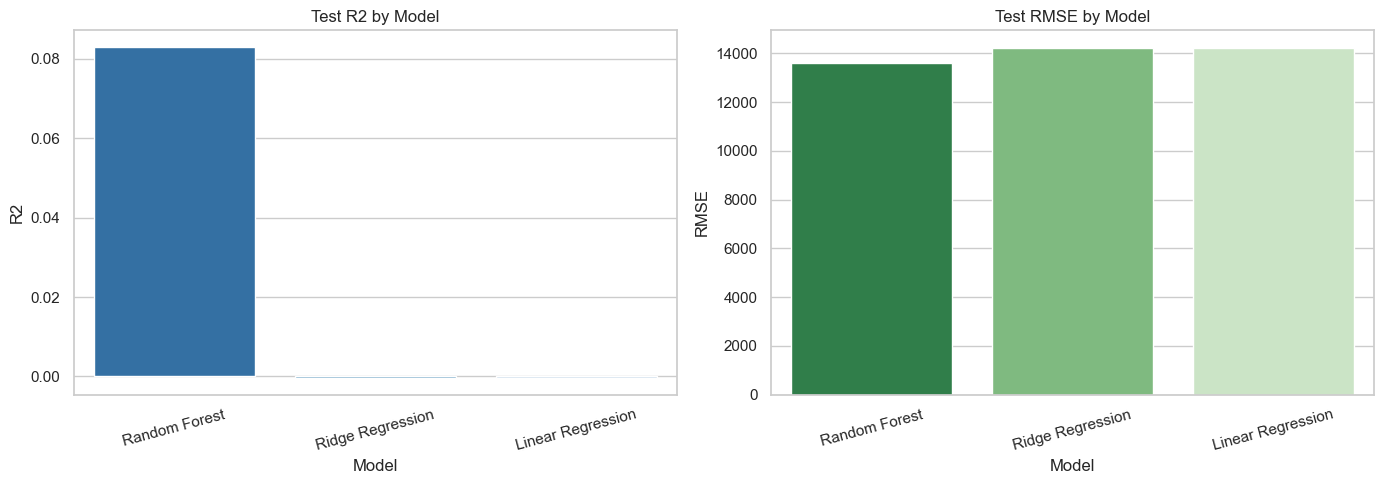

In [15]:
# Bar chart comparing R2 and RMSE across models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='Model', y='Test R2',
            ax=axes[0], palette='Blues_r')
axes[0].set_title('Test R2 by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R2')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=results_df, x='Model', y='Test RMSE',
            ax=axes[1], palette='Greens_r')
axes[1].set_title('Test RMSE by Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

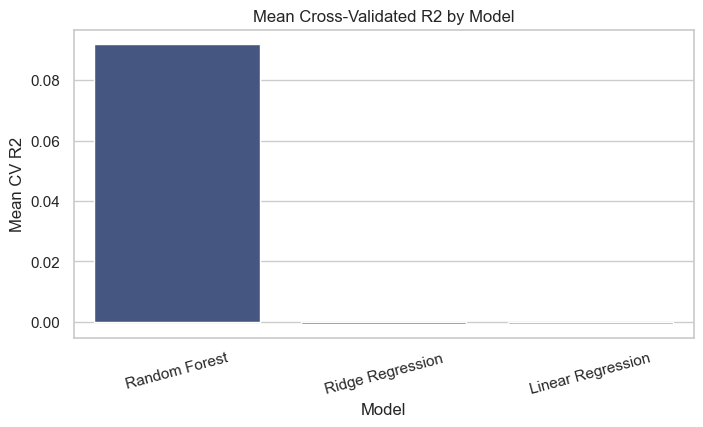

In [16]:
# Compare cross-validation R2 scores
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='Model', y='CV R2 Mean', palette='viridis')
plt.title('Mean Cross-Validated R2 by Model')
plt.xlabel('Model')
plt.ylabel('Mean CV R2')
plt.xticks(rotation=15)
plt.show()

## 5) Best Model Diagnostics

The random forest model had the strongest test performance, so the next visualizations show how its predictions compare with the true billing amounts.


In [11]:
# Predictions from the best model
best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]
best_predictions = best_pipeline.predict(X_test)
residuals = y_test - best_predictions

print('Best model:', best_model_name)
print('Test R2:', round(results_df.iloc[0]['Test R2'], 4))
print('Test RMSE:', round(results_df.iloc[0]['Test RMSE'], 2))

diagnostic_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': best_predictions,
    'Residual': residuals
})
diagnostic_df.head()

Best model: Random Forest
Test R2: 0.0829
Test RMSE: 13626.96


,Actual,Predicted,Residual
47632,38954.732218,23674.127743,15280.604475
28105,41672.625620,27128.577433,14544.048187
22395,46565.266671,26531.383178,20033.883493
47673,29218.582274,27278.815478,1939.766796
54365,16601.685137,21835.735236,-5234.050099


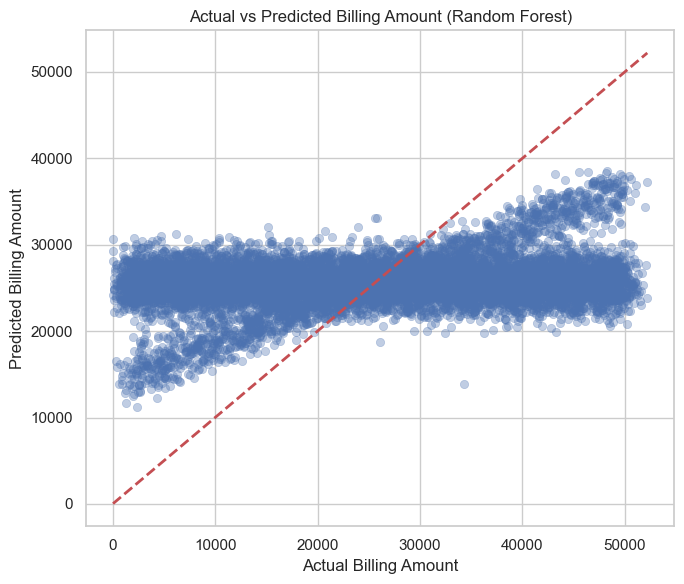

In [12]:
# Actual vs predicted plot for the best model
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.35, edgecolor=None)
max_value = max(y_test.max(), best_predictions.max())
min_value = min(y_test.min(), best_predictions.min())
plt.plot([min_value, max_value], [min_value, max_value], 'r--', linewidth=2)
plt.title(f'Actual vs Predicted Billing Amount ({best_model_name})')
plt.xlabel('Actual Billing Amount')
plt.ylabel('Predicted Billing Amount')
plt.tight_layout()
plt.show()

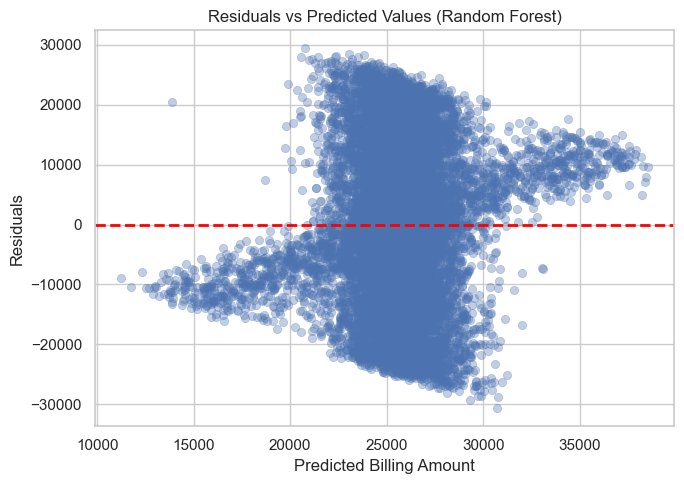

In [13]:
# Residual plot for the best model
plt.figure(figsize=(7, 5))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.35, edgecolor=None)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residuals vs Predicted Values ({best_model_name})')
plt.xlabel('Predicted Billing Amount')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

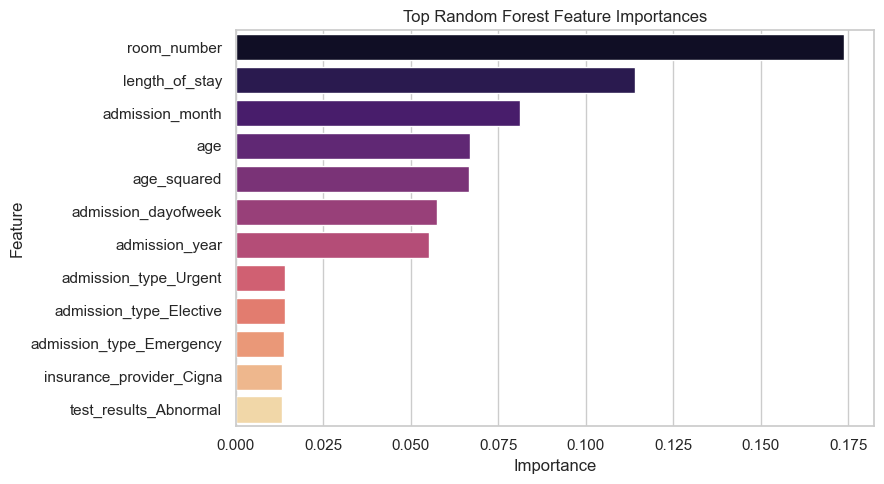

,Feature,Importance
1,room_number,0.173640
2,length_of_stay,0.113974
4,admission_month,0.081211
0,age,0.067033
7,age_squared,0.066559
5,admission_dayofweek,0.057514
3,admission_year,0.055175
31,admission_type_Urgent,0.014220
29,admission_type_Elective,0.014064
30,admission_type_Emergency,0.013881


In [17]:
# Approximate feature importance from the random forest model
# This is a quick interpretation aid for the best model.
rf_pipeline = trained_pipelines['Random Forest']
rf_model = rf_pipeline.named_steps['model']
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

numeric_features = numeric_cols
categorical_features = categorical_cols
onehot_features = preprocessor_fitted.named_transformers_[
    'cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, onehot_features])

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, y='Feature', x='Importance', palette='magma')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df

## 6) Summary of Results

### Performance Summary

- The **Random Forest** model performed best on the holdout test set and during cross-validation.
- The linear models, **Linear Regression** and **Ridge Regression**, produced nearly identical results and were much weaker than the random forest.
- The low-to-moderate $R^2$ values suggest that the available admission-time features explain only part of the variation in billing amount.

### Insights Gained

- Nonlinear relationships appear to matter more than a simple linear fit for this dataset.
- Billing amount is influenced by factors not fully captured in the available fields, so model performance is limited by feature availability.
- Feature engineering helped the tree-based model slightly, but the dataset may need stronger cost drivers such as diagnosis codes, procedure details, treatment counts, or utilization measures to achieve substantially better prediction accuracy.

### Conclusion

Deliverable 2 is complete with feature engineering, multiple regression models, performance metrics, cross-validation, and visual comparison. The random forest model was the best performer, but the modest $R^2$ also provides a useful data mining insight: the chosen features only weakly predict billing amount, so richer healthcare utilization variables would likely improve future models.
